In [2]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")


In [3]:
# Load the messy real-world dataset
df = pd.read_csv("smart_city_wifi_security_classification.csv")

# Preview dataset
df.head()


,session_duration_min,data_used_mb,device_type,login_failures,vpn_detected,country_mismatch,avg_packet_size_kb,hour_of_day,previous_flags,risk_class
0,41.222200,73.793204,Windows,4,No,0.0,9.524883,10,2,High_Risk
1,16.988193,81.895777,Android,1,Yes,0.0,0.347082,13,0,Suspicious
2,22.068542,826.543737,iOS,2,No,0.0,12.843110,0,2,High_Risk
3,52.422494,155.602219,Windows,1,Yes,0.0,3.151242,10,1,Suspicious
4,41.929770,274.262183,iOS,0,Yes,0.0,1.259792,16,0,Normal


In [5]:
# Dataset structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   session_duration_min  5096 non-null   float64
 1   data_used_mb          5200 non-null   float64
 2   device_type           4998 non-null   object 
 3   login_failures        5200 non-null   int64  
 4   vpn_detected          5002 non-null   object 
 5   country_mismatch      5044 non-null   float64
 6   avg_packet_size_kb    5200 non-null   float64
 7   hour_of_day           5200 non-null   int64  
 8   previous_flags        5200 non-null   int64  
 9   risk_class            5200 non-null   object 
dtypes: float64(4), int64(3), object(3)
memory usage: 406.4+ KB


In [6]:
# Statistical summary (helps detect outliers)
df.describe()


,session_duration_min,data_used_mb,login_failures,country_mismatch,avg_packet_size_kb,hour_of_day,previous_flags
count,5096.000000,5200.000000,5200.000000,5044.000000,5200.000000,5200.000000,5200.000000
mean,35.747978,536.613048,1.819615,0.162966,4.922350,11.596731,0.706923
std,18.686593,569.020231,1.355376,0.369371,2.873754,6.917942,0.855085
min,0.029361,0.142965,0.000000,0.000000,-1.000000,0.000000,0.000000
25%,21.999842,260.190117,1.000000,0.000000,2.743214,6.000000,0.000000
50%,35.258305,454.874854,2.000000,0.000000,4.873935,12.000000,0.000000
75%,48.241431,668.811284,3.000000,0.000000,6.890588,18.000000,1.000000
max,113.524754,7253.869949,8.000000,1.000000,14.840899,23.000000,5.000000


In [7]:
# Check missing values
df.isnull().sum()


session_duration_min    104
data_used_mb              0
device_type             202
login_failures            0
vpn_detected            198
country_mismatch        156
avg_packet_size_kb        0
hour_of_day               0
previous_flags            0
risk_class                0
dtype: int64

In [8]:
# Check class distribution
df["risk_class"].value_counts()


risk_class
Suspicious    2278
High_Risk     1889
Normal        1033
Name: count, dtype: int64

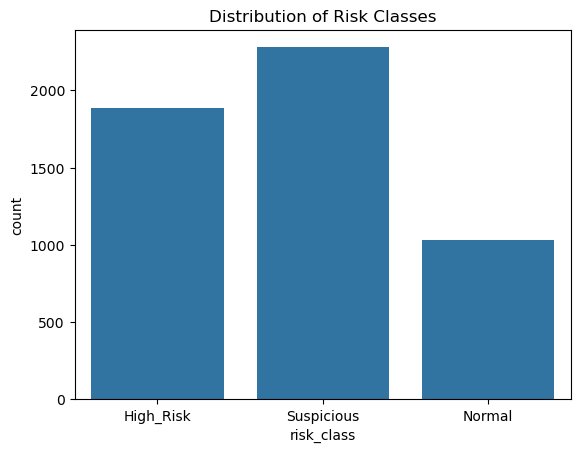

In [9]:
sns.countplot(x="risk_class", data=df)
plt.title("Distribution of Risk Classes")
plt.show()


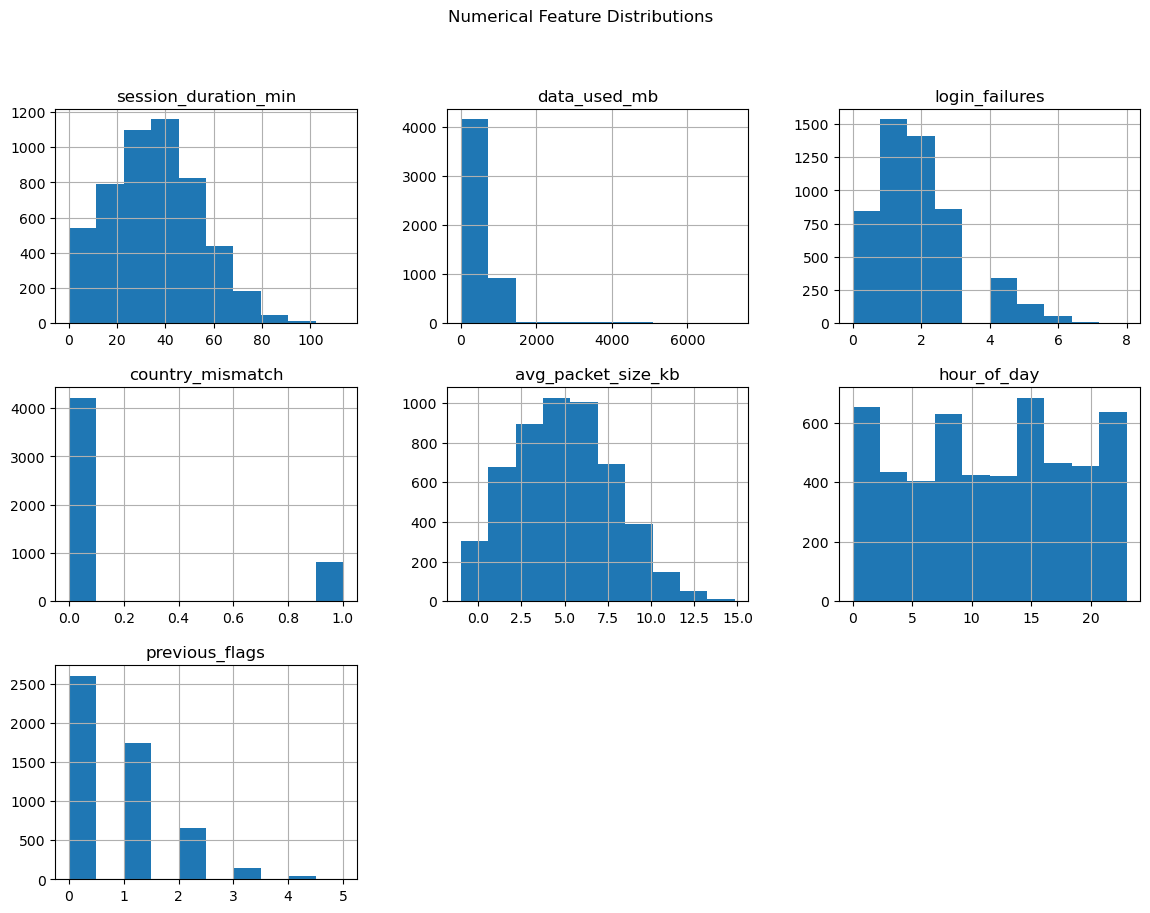

In [10]:
df.hist(figsize=(14,10))
plt.suptitle("Numerical Feature Distributions")
plt.show()


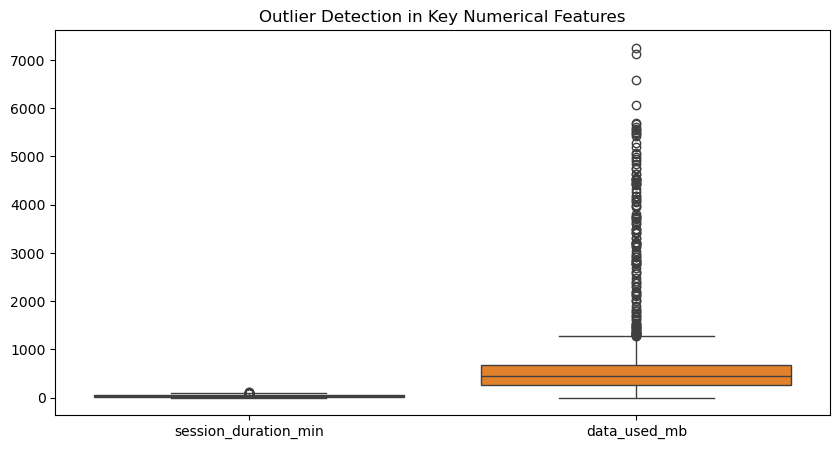

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df[["session_duration_min", "data_used_mb"]])
plt.title("Outlier Detection in Key Numerical Features")
plt.show()


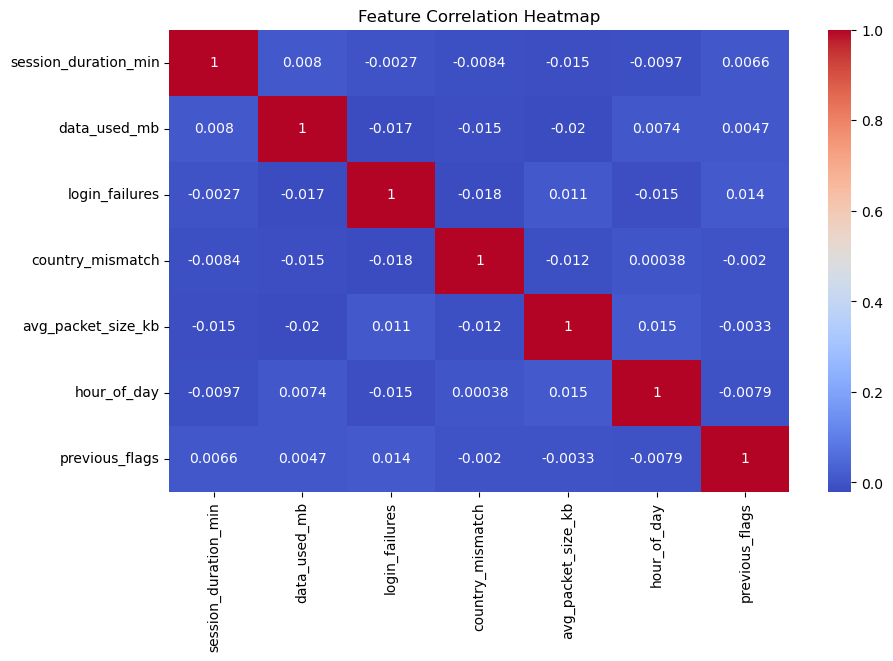

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [13]:
# Negative packet size is not possible in real networks
# Replace it with NaN so we can handle it properly
df.loc[df["avg_packet_size_kb"] < 0, "avg_packet_size_kb"] = np.nan


In [15]:
# Fill missing numerical values using median (robust to outliers)
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())



In [16]:
# Fill missing categorical values using mode
cat_cols = df.select_dtypes(include=["object"]).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")


In [17]:
# Encode categorical features
encoder = LabelEncoder()
for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])


In [18]:
# Encode target variable
target_encoder = LabelEncoder()
df["risk_class"] = target_encoder.fit_transform(df["risk_class"])


In [19]:
X = df.drop("risk_class", axis=1)
y = df["risk_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [21]:
def evaluate_model(name, model, y_test, predictions):
    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_test, predictions))
    print("\nClassification Report:\n", classification_report(y_test, predictions))
    
    sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt="d")
    plt.title(f"{name} – Confusion Matrix")
    plt.show()



Logistic Regression
----------------------------------------
Accuracy: 0.9838461538461538

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       472
           1       1.00      0.99      0.99       258
           2       0.97      0.99      0.98       570

    accuracy                           0.98      1300
   macro avg       0.99      0.98      0.99      1300
weighted avg       0.98      0.98      0.98      1300



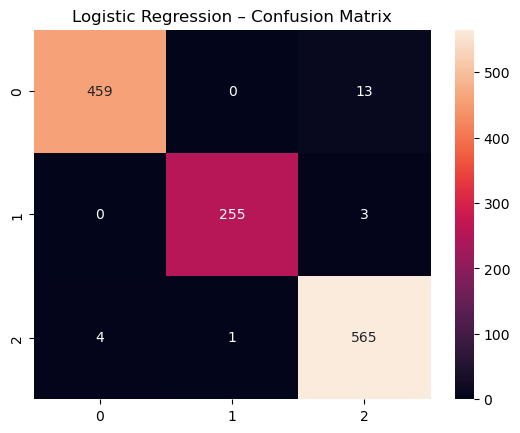

In [22]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

evaluate_model("Logistic Regression", lr, y_test, lr_pred)



Decision Tree
----------------------------------------
Accuracy: 0.9492307692307692

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96       472
           1       0.89      1.00      0.94       258
           2       0.94      0.95      0.94       570

    accuracy                           0.95      1300
   macro avg       0.94      0.96      0.95      1300
weighted avg       0.95      0.95      0.95      1300



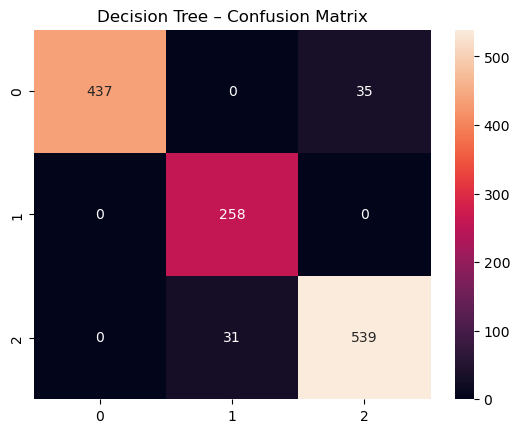

In [23]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

evaluate_model("Decision Tree", dt, y_test, dt_pred)



Random Forest
----------------------------------------
Accuracy: 0.9953846153846154

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       472
           1       1.00      1.00      1.00       258
           2       0.99      1.00      0.99       570

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



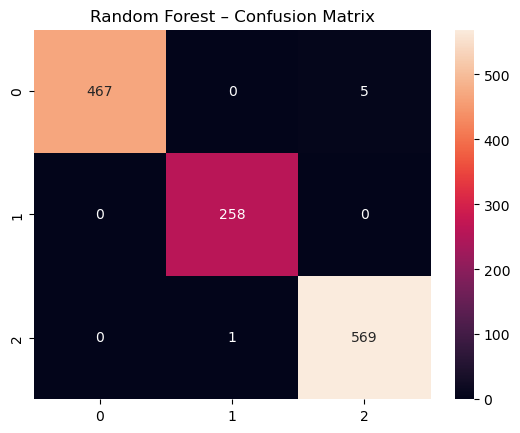

In [24]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

evaluate_model("Random Forest", rf, y_test, rf_pred)



Gradient Boosting
----------------------------------------
Accuracy: 0.9976923076923077

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       472
           1       1.00      1.00      1.00       258
           2       1.00      1.00      1.00       570

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



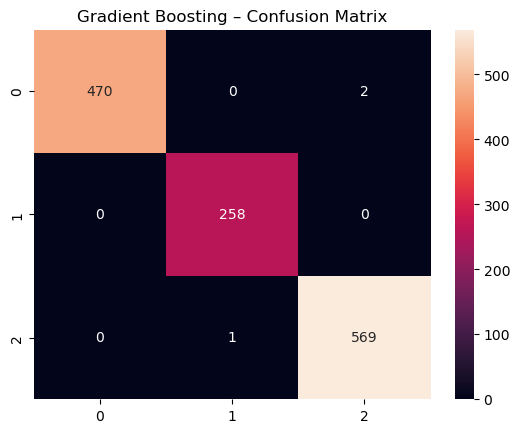

In [25]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

evaluate_model("Gradient Boosting", gb, y_test, gb_pred)



XGBoost
----------------------------------------
Accuracy: 0.9961538461538462

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       472
           1       1.00      1.00      1.00       258
           2       1.00      0.99      1.00       570

    accuracy                           1.00      1300
   macro avg       1.00      1.00      1.00      1300
weighted avg       1.00      1.00      1.00      1300



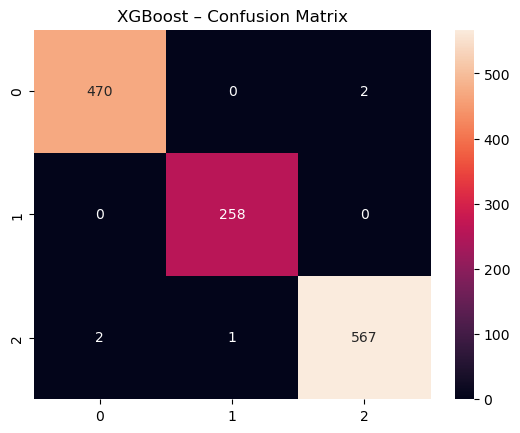

In [26]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

evaluate_model("XGBoost", xgb, y_test, xgb_pred)


In [27]:
# Simulated new Wi-Fi session
new_data = np.array([[45, 900, 2, 3, 1, 1, 6, 22, 2]])

new_data_scaled = scaler.transform(new_data)

prediction = xgb.predict(new_data_scaled)
print("Predicted Risk Class:", target_encoder.inverse_transform(prediction))


Predicted Risk Class: [0]
